In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
df = pd.read_csv("iris.csv", header=None, names=columns)

df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Number of Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Number of Rows and Columns:
(150, 5)

Column Names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [4]:
df.isnull().sum()


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
df.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


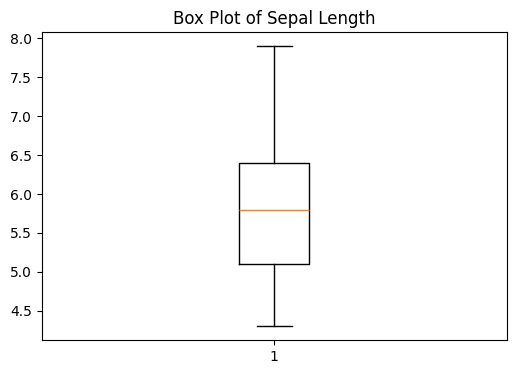

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["sepal_length"])
plt.title("Box Plot of Sepal Length")
plt.show()


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["sepal_length_normalized"] = scaler.fit_transform(df[["sepal_length"]])

df[["sepal_length","sepal_length_normalized"]].head()


,sepal_length,sepal_length_normalized
0,5.1,0.222222
1,4.9,0.166667
2,4.7,0.111111
3,4.6,0.083333
4,5.0,0.194444


In [10]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

df["petal_length_standardized"] = standard.fit_transform(df[["petal_length"]])

df[["petal_length","petal_length_standardized"]].head()


,petal_length,petal_length_standardized
0,1.4,-1.341272
1,1.4,-1.341272
2,1.3,-1.398138
3,1.5,-1.284407
4,1.4,-1.341272


In [11]:
df.groupby("species")["sepal_length"].mean()


species
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: sepal_length, dtype: float64

In [12]:
df["Sepal_Category"] = pd.cut(
    df["sepal_length"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

df[["sepal_length","Sepal_Category"]].head()


,sepal_length,Sepal_Category
0,5.1,Low
1,4.9,Low
2,4.7,Low
3,4.6,Low
4,5.0,Low


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Species_Label"] = encoder.fit_transform(df["species"])

df[["species","Species_Label"]].head()


,species,Species_Label
0,Iris-setosa,0
1,Iris-setosa,0
2,Iris-setosa,0
3,Iris-setosa,0
4,Iris-setosa,0


In [14]:
df_encoded = pd.get_dummies(df, columns=["Sepal_Category"])

df_encoded.head()


,sepal_length,sepal_width,petal_length,petal_width,species,sepal_length_normalized,petal_length_standardized,Species_Label,Sepal_Category_Low,Sepal_Category_Medium,Sepal_Category_High
0,5.1,3.5,1.4,0.2,Iris-setosa,0.222222,-1.341272,0,True,False,False
1,4.9,3.0,1.4,0.2,Iris-setosa,0.166667,-1.341272,0,True,False,False
2,4.7,3.2,1.3,0.2,Iris-setosa,0.111111,-1.398138,0,True,False,False
3,4.6,3.1,1.5,0.2,Iris-setosa,0.083333,-1.284407,0,True,False,False
4,5.0,3.6,1.4,0.2,Iris-setosa,0.194444,-1.341272,0,True,False,False


In [15]:
df_reduced = df.drop(columns=["petal_width"])

df_reduced.head()


,sepal_length,sepal_width,petal_length,species,sepal_length_normalized,petal_length_standardized,Sepal_Category,Species_Label
0,5.1,3.5,1.4,Iris-setosa,0.222222,-1.341272,Low,0
1,4.9,3.0,1.4,Iris-setosa,0.166667,-1.341272,Low,0
2,4.7,3.2,1.3,Iris-setosa,0.111111,-1.398138,Low,0
3,4.6,3.1,1.5,Iris-setosa,0.083333,-1.284407,Low,0
4,5.0,3.6,1.4,Iris-setosa,0.194444,-1.341272,Low,0


In [16]:
df.sample(5)


,sepal_length,sepal_width,petal_length,petal_width,species,sepal_length_normalized,petal_length_standardized,Sepal_Category,Species_Label
88,5.6,3.0,4.1,1.3,Iris-versicolor,0.361111,0.194102,Medium,1
51,6.4,3.2,4.5,1.5,Iris-versicolor,0.583333,0.421564,Medium,1
47,4.6,3.2,1.4,0.2,Iris-setosa,0.083333,-1.341272,Low,0
103,6.3,2.9,5.6,1.8,Iris-virginica,0.555556,1.047087,Medium,2
86,6.7,3.1,4.7,1.5,Iris-versicolor,0.666667,0.535296,Medium,1


In [17]:
df.to_csv("preprocessed_iris.csv", index=False)

print("Preprocessed dataset saved successfully!")


Preprocessed dataset saved successfully!
